# Differential Expression: Autophagy-Targeted

This notebook runs pseudobulk differential expression for broad Harmony classes and excitatory-focus subclasses, then keeps and inspects the predefined autophagy-related gene panel.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sys.path.append(str(Path("../src").resolve()))
from c9_snrnaseq.io_utils import PROJECT_ROOT


In [2]:
RESULTS_DIR = PROJECT_ROOT / "results"
DE_BROAD_DIR = RESULTS_DIR / "de_pseudobulk_broad"
DE_EXC_DIR = RESULTS_DIR / "de_pseudobulk_exc_focus"
FIGURES_DIR = RESULTS_DIR / "figures"

for d in [RESULTS_DIR, DE_BROAD_DIR, DE_EXC_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

adata_merged_pb = sc.read_h5ad(PROJECT_ROOT / "data/processed/merged/adata_merged_pb_exc_focus.h5ad")

print(adata_merged_pb.shape)
print("Has counts:", "counts" in adata_merged_pb.layers)
print("Has cell_class_major_harmony:", "cell_class_major_harmony" in adata_merged_pb.obs.columns)
print("Has exc_subclass_focus:", "exc_subclass_focus" in adata_merged_pb.obs.columns)
print(adata_merged_pb.obs["exc_subclass_focus"].value_counts(dropna=False))


(89819, 61552)
Has counts: True
Has cell_class_major_harmony: True
Has exc_subclass_focus: True
exc_subclass_focus
NaN                      70013
Other_excitatory         15810
Projection_like_SCN4B     2198
Broad_IT_exc              1592
UMN_like_VAT1L             206
Name: count, dtype: int64


In [12]:
broad_main_classes = [
    "Microglia",
    "Excitatory_neurons",
    "Astrocytes",
    "Inhibitory_neurons",
    "OPCs",
]

exc_focus_de_classes = [
    "Projection_like_SCN4B",
    "Broad_IT_exc",
]

pairwise_tests = [
    ("Control", "sALS"),
    ("Control", "c9ALS"),
    ("sALS", "c9ALS"),
]

autophagy_genes = [
    # C9/autophagy core
    "C9orf72", "SMCR8", "WDR41",
    "ULK1", "ULK2", "RB1CC1", "ATG13", "ATG101",
    "BECN1", "PIK3C3", "ATG14", "WIPI2",
    "ATG5", "ATG7", "ATG12", "ATG16L1",
    "MAP1LC3B", "GABARAPL1", "GABARAPL2",
    "SQSTM1", "OPTN", "CALCOCO2", "TAX1BP1", "NBR1",
    "TBK1", "LAMP1", "LAMP2", "RAB7A", "CTSD",

    # canonical mitophagy
    "PINK1", "PRKN", "BNIP3", "BNIP3L", "FUNDC1",
    "PHB2", "BCL2L13", "FKBP8",

    # mitochondria dynamics: fission / fusion
    "DNM1L", "FIS1", "MFF", "MIEF1", "MIEF2",
    "MFN1", "MFN2", "OPA1",

    # mitochondrial transport / membrane / contact / turnover relevance
    "RHOT1", "RHOT2", "VDAC1", "TOMM20", "TOMM70",
    "TIMM23", "TIMM44",

    # mitochondrial proteostasis / UPRmt / stress response
    "LONP1", "CLPP", "CLPX", "AFG3L2", "SPG7",
    "HSPD1", "HSPE1", "DNAJA3",

    # mitochondrial biogenesis / transcriptional control
    "PPARGC1A", "PPARGC1B", "NRF1", "NRF2", "TFAM",
    "TFB1M", "TFB2M", "POLG", "POLG2",

    # respiration / mitochondrial function / homeostasis
    "NDUFS1", "NDUFV1", "SDHA", "UQCRC1", "COX4I1", "ATP5F1A",
    "SOD2", "PRDX3", "GPX4", "TXN2",

    # mitochondrial membrane potential / calcium / permeability transition
    "IMMT", "MICOS10", "MCU", "MICU1", "MICU2",
    "SLC25A4", "SLC25A5",

    # lysosome / acidification / autophagosome-lysosome axis
    "ATP6V1A", "ATP6V0C", "RAB9A", "UVRAG", "VPS11", "VPS16"
]


In [ ]:
def pseudobulk_by_sample(
    adata,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts",
):
    sub = adata[adata.obs[groupby_col] == group_value].copy()
    if sub.n_obs == 0:
        raise ValueError(f"No cells found for {groupby_col}={group_value!r}.")

    cell_counts = sub.obs["sample"].value_counts()
    keep_samples = cell_counts[cell_counts >= min_cells_per_sample].index.tolist()
    if not keep_samples:
        raise ValueError(
            f"No samples retained for {groupby_col}={group_value!r} "
            f"with min_cells_per_sample={min_cells_per_sample}."
        )

    sub = sub[sub.obs["sample"].isin(keep_samples)].copy()
    sample_order = sorted(sub.obs["sample"].unique())
    pb_counts = []
    pb_meta = []

    for samp in sample_order:
        ss = sub[sub.obs["sample"] == samp]
        x = ss.layers[layer]
        if hasattr(x, "toarray"):
            x = x.toarray()
        pb_counts.append(np.asarray(x.sum(axis=0)).ravel())
        pb_meta.append({
            "sample": samp,
            "condition": ss.obs["condition"].iloc[0],
            "group_value": group_value,
            "groupby_col": groupby_col,
            "n_cells": ss.n_obs,
        })

    counts_df = pd.DataFrame(pb_counts, index=sample_order, columns=sub.var_names)
    meta_df = pd.DataFrame(pb_meta).set_index("sample")
    return counts_df, meta_df


def run_pairwise_deseq(counts_df, meta_df, group_a, group_b):
    keep = meta_df["condition"].isin([group_a, group_b])
    counts_use = counts_df.loc[keep].copy()
    meta_use = meta_df.loc[keep].copy()

    counts_use = counts_use.round().astype(int)

    dds = DeseqDataSet(
        counts=counts_use,
        metadata=meta_use,
        design_factors="condition",
        refit_cooks=True,
    )
    dds.deseq2()

    stats = DeseqStats(dds, contrast=["condition", group_b, group_a])
    stats.summary()

    res = stats.results_df.copy()
    res["gene"] = res.index
    return res


In [7]:
broad_de_results = {}
exc_focus_de_results = {}
skipped_groups = []

for ct in broad_main_classes:
    counts_df, meta_df = pseudobulk_by_sample(
        adata_merged_pb,
        group_value=ct,
        groupby_col="cell_class_major_harmony",
        min_cells_per_sample=20,
        layer="counts",
    )
    for g1, g2 in pairwise_tests:
        res = run_pairwise_deseq(counts_df, meta_df, g1, g2)
        res_panel = res[res["gene"].isin(autophagy_genes)].copy()
        res_panel.to_csv(DE_BROAD_DIR / f"{ct}_{g1}_vs_{g2}_mito_qc.csv", index=False)
        broad_de_results[(ct, g1, g2)] = res_panel

for ct in exc_focus_de_classes:
    try:
        counts_df, meta_df = pseudobulk_by_sample(
            adata_merged_pb,
            group_value=ct,
            groupby_col="exc_subclass_focus",
            min_cells_per_sample=20,
            layer="counts",
        )
    except ValueError as e:
        skipped_groups.append((ct, str(e)))
        print(f"Skipping {ct}: {e}")
        continue

    for g1, g2 in pairwise_tests:
        res = run_pairwise_deseq(counts_df, meta_df, g1, g2)
        res_panel = res[res["gene"].isin(autophagy_genes)].copy()
        res_panel.to_csv(DE_EXC_DIR / f"{ct}_{g1}_vs_{g2}_mito_qc.csv", index=False)
        exc_focus_de_results[(ct, g1, g2)] = res_panel

print("Skipped groups:", skipped_groups)


/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_32936/4212050889.py:51: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.90 seconds.

Fitting dispersion trend curve...
/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.34 seconds.

Fitting MAP dispersions...
... done in 2.71 seconds.

Fitting LFCs...
... done in 1.80 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.42 seconds.

/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_32936/4212050889.py:51: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value: condition sALS vs Control
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TNFRSF4            1.034081       -2.192065  1.552488 -1.411970  0.157959   
TNFRSF18           2.414928       -0.793367  0.995548 -0.796915  0.425500   
ATAD3B           109.301367       -0.375897  0.214692 -1.750866  0.079969   
ENSG00000260179    0.890648       -0.957897  1.367508 -0.700469  0.483634   
ENSG00000234396    4.290725       -0.244511  0.626065 -0.390552  0.696129   
...                     ...             ...       ...       ...       ...   
ENSG00000271254  153.590918        0.034278  0.420403  0.081536  0.935016   
U1-4               0.000000             NaN       NaN       NaN       NaN   
ENSG00000268674    0.146448       -1.650441  2.733157 -0.603859  0.545938   
ENSG00000277475    0.000000             NaN       NaN       NaN       NaN   
U1-5               0.721429       -2.368560  1.821592 -1.300269  0.193509   

           

Fitting dispersions...
... done in 1.83 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 2.15 seconds.

Fitting LFCs...
... done in 1.75 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.39 seconds.

/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_32936/4212050889.py:51: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.



...

Fitting dispersions...
... done in 1.35 seconds.

Fitting dispersion trend curve...
... done in 0.26 seconds.

Fitting MAP dispersions...
... done in 1.39 seconds.

Fitting LFCs...
... done in 1.56 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.43 seconds.

/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_32936/4212050889.py:51: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value: condition c9ALS vs Control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TNFRSF4          0.000000             NaN       NaN       NaN       NaN   
TNFRSF18         0.000000             NaN       NaN       NaN       NaN   
ATAD3B           6.032006       -0.064828  0.611220 -0.106063  0.915532   
ENSG00000260179  0.000000             NaN       NaN       NaN       NaN   
ENSG00000234396  0.297037        1.614999  3.027376  0.533465  0.593712   
...                   ...             ...       ...       ...       ...   
ENSG00000271254  2.152331       -1.092679  1.002880 -1.089540  0.275916   
U1-4             0.000000             NaN       NaN       NaN       NaN   
ENSG00000268674  0.000000             NaN       NaN       NaN       NaN   
ENSG00000277475  0.000000             NaN       NaN       NaN       NaN   
U1-5             0.000000             NaN       NaN       NaN       NaN   

                     padj  
TNFRSF

Fitting dispersions...
... done in 1.31 seconds.

Fitting dispersion trend curve...
/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.25 seconds.

Fitting MAP dispersions...
... done in 1.88 seconds.

Fitting LFCs...
... done in 1.62 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition c9ALS vs sALS
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TNFRSF4          0.000000             NaN       NaN       NaN       NaN   
TNFRSF18         0.053566        0.750521  3.230057  0.232355  0.816262   
ATAD3B           6.284723        0.693725  0.581736  1.192509  0.233062   
ENSG00000260179  0.000000             NaN       NaN       NaN       NaN   
ENSG00000234396  0.667486        0.512683  1.359520  0.377106  0.706095   
...                   ...             ...       ...       ...       ...   
ENSG00000271254  2.351119       -0.695453  0.853753 -0.814583  0.415311   
U1-4             0.000000             NaN       NaN       NaN       NaN   
ENSG00000268674  0.000000             NaN       NaN       NaN       NaN   
ENSG00000277475  0.000000             NaN       NaN       NaN       NaN   
U1-5             0.000000             NaN       NaN       NaN       NaN   

                     padj  
TNFRSF4  

... done in 1.40 seconds.



In [25]:
RESULT_DIRS = {
    "broad": DE_BROAD_DIR,
    "exc_focus": DE_EXC_DIR,
}

def format_comparison_for_display(comparison):
    g1, g2 = comparison.split("_vs_")
    return f"{g2} vs {g1}"


def load_de_result(analysis_level, group_name, comparison, suffix="_mito_qc.csv"):
    fn = RESULT_DIRS[analysis_level] / f"{group_name}_{comparison}{suffix}"
    if not fn.exists():
        raise FileNotFoundError(f"Result file not found: {fn}")
    df = pd.read_csv(fn)
    df["analysis_level"] = analysis_level
    df["group_name"] = group_name
    df["comparison"] = comparison
    return df


def plot_volcano(analysis_level, group_name, comparison, genes_to_label=None, padj_cutoff=0.1, lfc_cutoff=0.5):
    df = load_de_result(analysis_level, group_name, comparison).dropna(subset=["padj", "log2FoldChange"]).copy()
    df["neglog10_padj"] = -np.log10(df["padj"].clip(lower=1e-300))
    df["sig"] = "NS"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] > lfc_cutoff), "sig"] = "Up"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] < -lfc_cutoff), "sig"] = "Down"

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {"NS": "lightgray", "Up": "firebrick", "Down": "steelblue"}
    for label in ["NS", "Up", "Down"]:
        sub = df[df["sig"] == label]
        ax.scatter(sub["log2FoldChange"], sub["neglog10_padj"], s=28, alpha=0.8, color=colors[label], label=label)

    if genes_to_label:
        label_df = df[df["gene"].isin(genes_to_label)].copy()
        for _, row in label_df.iterrows():
            ax.text(row["log2FoldChange"], row["neglog10_padj"], row["gene"], fontsize=8)

    ax.axvline(lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axvline(-lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axhline(-np.log10(padj_cutoff), linestyle="--", color="black", linewidth=1)
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(f"{group_name} | {format_comparison_for_display(comparison)}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return df


def plot_log2fc_heatmap(analysis_level, group_names, comparisons, genes, ytick_fontsize=8):
    long_dfs = []
    for group_name in group_names:
        for comparison in comparisons:
            df = load_de_result(analysis_level, group_name, comparison).dropna(subset=["padj", "log2FoldChange"]).copy()
            df["row"] = f"{group_name} | {format_comparison_for_display(comparison)}"
            long_dfs.append(df[["gene", "row", "log2FoldChange"]])

    long_df = pd.concat(long_dfs, ignore_index=True)
    long_df = long_df[long_df["gene"].isin(genes)].copy()
    mat = long_df.pivot_table(index="gene", columns="row", values="log2FoldChange", fill_value=0)
    mat = mat.loc[[g for g in genes if g in mat.index]]

    vmax = np.nanmax(np.abs(mat.values)) if mat.size else 1
    fig_h = max(8, 0.28 * max(len(mat.index), 1))
    fig, ax = plt.subplots(figsize=(14, fig_h))
    im = ax.imshow(mat.values, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=ytick_fontsize)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_title(f"log2FC heatmap | {analysis_level}")
    plt.colorbar(im, ax=ax, label="log2 fold change")
    plt.tight_layout()
    plt.show()
    return mat


def summarize_gene(gene, analysis_level, group_names, comparisons):
    rows = []
    for group_name in group_names:
        for comparison in comparisons:
            df = load_de_result(analysis_level, group_name, comparison)
            df["comparison"] = format_comparison_for_display(comparison)
            hit = df[df["gene"] == gene].copy()
            if not hit.empty:
                rows.append(hit)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    keep_cols = [c for c in ["analysis_level", "group_name", "comparison", "gene", "log2FoldChange", "padj", "pvalue", "baseMean"] if c in out.columns]
    return out[keep_cols].sort_values(["group_name", "comparison"]).reset_index(drop=True)


def plot_gene_by_condition(
    adata,
    gene,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts",
    normalisation="CPM",
    figsize=(6, 5),
):
    counts_df, meta_df = pseudobulk_by_sample(
        adata,
        group_value=group_value,
        groupby_col=groupby_col,
        min_cells_per_sample=min_cells_per_sample,
        layer=layer,
    )

    if gene not in counts_df.columns:
        raise ValueError(f"{gene} not found in pseudobulk counts.")

    plot_df = meta_df.copy()

    if normalisation.upper() == "CPM":
        libsize = counts_df.sum(axis=1)
        expr = np.log1p(counts_df.div(libsize, axis=0) * 1e6)
        ylab = f"log1p(CPM) of {gene}"
    else:
        expr = np.log1p(counts_df[gene])
        ylab = f"log1p(raw pseudobulk count) of {gene}"

    plot_df["expr"] = expr[gene] if normalisation.upper() == "CPM" else expr

    cond_order = ["Control", "sALS", "c9ALS"]
    x_pos = {cond: i for i, cond in enumerate(cond_order)}

    fig, ax = plt.subplots(figsize=figsize)

    for cond in cond_order:
        sub = plot_df[plot_df["condition"] == cond].copy()
        if sub.empty:
            continue

        jitter = np.linspace(-0.08, 0.08, len(sub)) if len(sub) > 1 else np.array([0.0])
        xs = np.full(len(sub), x_pos[cond]) + jitter

        ax.scatter(xs, sub["expr"], s=50, alpha=0.9, label=cond)

        for x, (_, row) in zip(xs, sub.iterrows()):
            ax.text(x, row["expr"], row.name, fontsize=7, alpha=0.8)

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels(cond_order)
    ax.set_ylabel(ylab)
    ax.set_title(f"{gene} in {group_value}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return plot_df


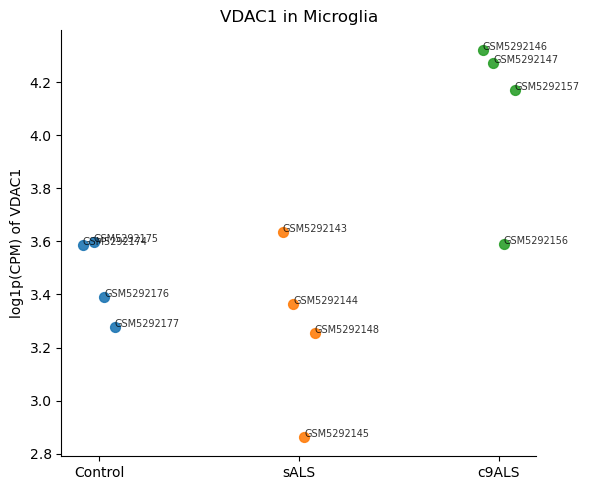

,condition,group_value,groupby_col,n_cells,expr
sample,,,,,
GSM5292143,sALS,Microglia,cell_class_major_harmony,1426,3.635588
GSM5292144,sALS,Microglia,cell_class_major_harmony,2669,3.364199
GSM5292145,sALS,Microglia,cell_class_major_harmony,1448,2.862796
GSM5292146,c9ALS,Microglia,cell_class_major_harmony,1502,4.323352
GSM5292147,c9ALS,Microglia,cell_class_major_harmony,1638,4.272458
GSM5292148,sALS,Microglia,cell_class_major_harmony,2169,3.252938
GSM5292156,c9ALS,Microglia,cell_class_major_harmony,1353,3.591648
GSM5292157,c9ALS,Microglia,cell_class_major_harmony,1279,4.171827
GSM5292174,Control,Microglia,cell_class_major_harmony,1191,3.584921


In [20]:
plot_gene_by_condition(
    adata_merged_pb,
    gene="VDAC1",
    group_value="Microglia",
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
)

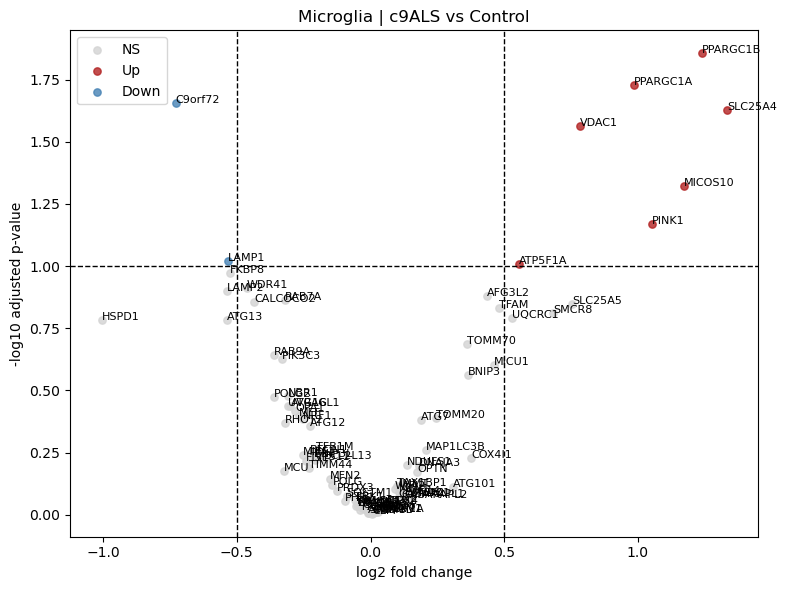

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,analysis_level,group_name,comparison,neglog10_padj,sig
0,90.587307,1.172683,0.419187,2.797515,0.005150,0.047682,MICOS10,broad,Microglia,Control_vs_c9ALS,1.321644,Up
1,34.903293,0.028396,0.370306,0.076683,0.938876,0.973677,TFB2M,broad,Microglia,Control_vs_c9ALS,0.011585,NS
2,431.760251,0.243346,0.177165,1.373558,0.169579,0.407037,TOMM20,broad,Microglia,Control_vs_c9ALS,0.390366,NS
3,141.870301,1.053417,0.402424,2.617680,0.008853,0.067834,PINK1,broad,Microglia,Control_vs_c9ALS,1.168550,Up
4,130.717673,-0.151506,0.216811,-0.698793,0.484682,0.715438,MFN2,broad,Microglia,Control_vs_c9ALS,0.145428,NS
...,...,...,...,...,...,...,...,...,...,...,...,...
86,134.341332,-0.047260,0.222417,-0.212482,0.831731,0.925727,LONP1,broad,Microglia,Control_vs_c9ALS,0.033517,NS
87,319.301707,0.066156,0.255127,0.259305,0.795400,0.909529,GPX4,broad,Microglia,Control_vs_c9ALS,0.041183,NS
88,63.284523,-0.252453,0.252241,-1.000841,0.316904,0.573195,MIEF1,broad,Microglia,Control_vs_c9ALS,0.241698,NS
89,401.046100,-0.175376,0.186021,-0.942775,0.345796,0.599655,BCL2L13,broad,Microglia,Control_vs_c9ALS,0.222098,NS


In [26]:
plot_volcano(
    # analysis_level can be "broad" or "exc_focus".
    analysis_level="broad",
    # group_name can be 
        # broad: "Excitatory_neurons", "Inhibitory_neurons", "Astrocytes", "Microglia", "OPCs".
        # exc_focus: "Projection_like_SCN4B", "Broad_IT_exc".
    group_name="Microglia",
    # comparison can be "Control_vs_sALS", "Control_vs_c9ALS", "sALS_vs_c9ALS".
    comparison="Control_vs_c9ALS",
    genes_to_label=autophagy_genes,
)


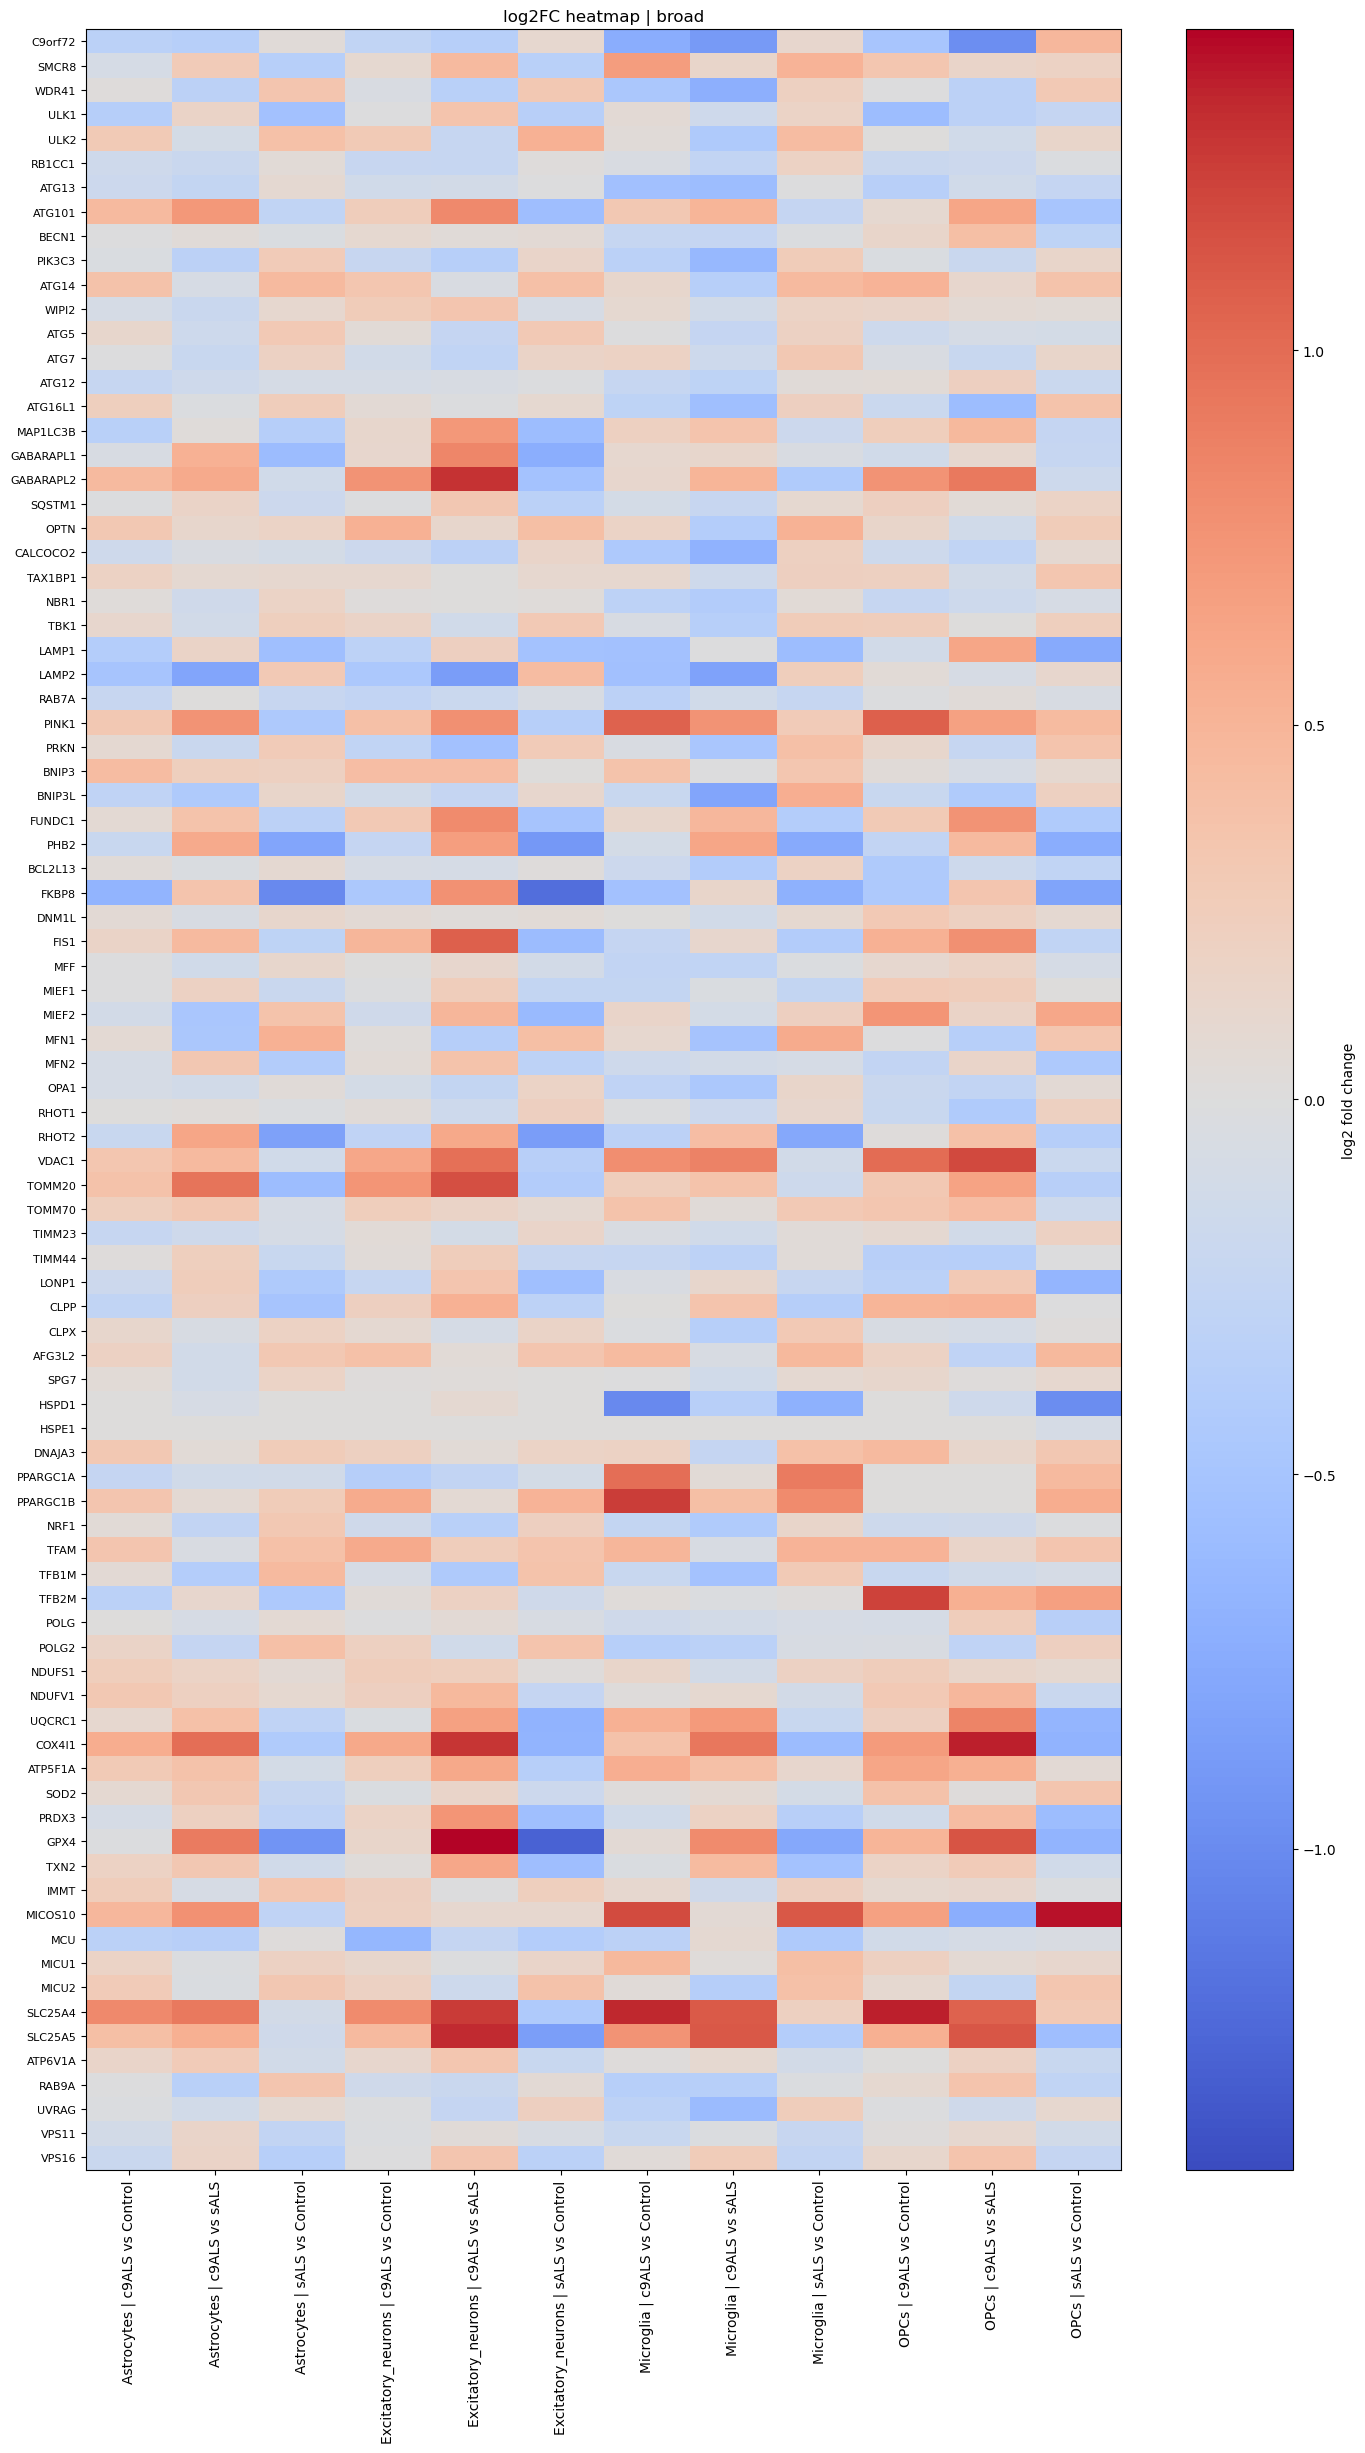

row,Astrocytes | c9ALS vs Control,Astrocytes | c9ALS vs sALS,Astrocytes | sALS vs Control,Excitatory_neurons | c9ALS vs Control,Excitatory_neurons | c9ALS vs sALS,Excitatory_neurons | sALS vs Control,Microglia | c9ALS vs Control,Microglia | c9ALS vs sALS,Microglia | sALS vs Control,OPCs | c9ALS vs Control,OPCs | c9ALS vs sALS,OPCs | sALS vs Control
gene,,,,,,,,,,,,
C9orf72,-0.324851,-0.364724,0.038518,-0.272458,-0.365532,0.101414,-0.729048,-0.883958,0.120572,-0.482646,-0.980221,0.469990
SMCR8,-0.083850,0.271858,-0.358337,0.098164,0.454238,-0.338126,0.683022,0.136921,0.511977,0.333206,0.154453,0.186042
WDR41,0.019565,-0.321972,0.337327,-0.050430,-0.345313,0.302384,-0.462461,-0.712997,0.211297,-0.006073,-0.313616,0.298620
ULK1,-0.372527,0.157616,-0.530580,-0.010469,0.353203,-0.354076,0.062306,-0.147951,0.176566,-0.573080,-0.313726,-0.244093
ULK2,0.285403,-0.100232,0.383953,0.282784,-0.233858,0.525178,0.041101,-0.427422,0.432667,0.011045,-0.133106,0.138517
...,...,...,...,...,...,...,...,...,...,...,...,...
ATP6V1A,0.150856,0.268004,-0.116965,0.116725,0.331335,-0.204512,0.018159,0.092152,-0.107279,0.004065,0.196750,-0.209624
RAB9A,-0.010789,-0.344837,0.335011,-0.143375,-0.197744,0.057997,-0.361345,-0.366374,-0.033412,0.092369,0.348948,-0.275368
UVRAG,-0.030670,-0.118955,0.086650,-0.019386,-0.234477,0.222844,-0.307215,-0.593292,0.252214,-0.015704,-0.138484,0.110223


In [27]:
plot_log2fc_heatmap(
    analysis_level="broad",
    group_names=["Microglia", "Excitatory_neurons", "Astrocytes", "OPCs"],
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
    genes=autophagy_genes,
)

In [28]:
summarize_gene(
    gene="SMCR8",
    analysis_level="broad",
    group_names=["Microglia", "Excitatory_neurons", "Astrocytes", "Inhibitory_neurons", "OPCs"],
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
)

,analysis_level,group_name,comparison,gene,log2FoldChange,padj,pvalue,baseMean
0,broad,Astrocytes,c9ALS vs Control,SMCR8,-0.083850,0.952162,0.776420,32.246036
1,broad,Astrocytes,c9ALS vs sALS,SMCR8,0.271858,0.645464,0.402422,25.007847
2,broad,Astrocytes,sALS vs Control,SMCR8,-0.358337,0.512924,0.236209,29.434345
3,broad,Excitatory_neurons,c9ALS vs Control,SMCR8,0.098164,0.865739,0.677475,154.880356
4,broad,Excitatory_neurons,c9ALS vs sALS,SMCR8,0.454238,0.206365,0.073867,142.289359
5,broad,Excitatory_neurons,sALS vs Control,SMCR8,-0.338126,0.383577,0.119649,99.419873
6,broad,Inhibitory_neurons,c9ALS vs Control,SMCR8,-0.175421,0.890312,0.582381,80.576572
7,broad,Inhibitory_neurons,c9ALS vs sALS,SMCR8,0.598553,0.194470,0.049413,49.697052
8,broad,Inhibitory_neurons,sALS vs Control,SMCR8,-0.780291,0.206665,0.034296,44.294599
9,broad,Microglia,c9ALS vs Control,SMCR8,0.683022,0.154737,0.033713,32.715018
